# Healthcare Hospital Operations Data Analysis Project

In [6]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

sns.set_style("whitegrid")

In [7]:
# INTRODUCTION
display(Markdown("## **INTRODUCTION**"))

display(Markdown("### **Healthcare systems generate large amounts of operational data related to patient admissions, treatment costs, hospital departments, and discharge outcomes. Analyzing this data helps hospitals understand patient trends, optimize resource allocation, and improve operational efficiency.**"))

display(Markdown("### **This project analyzes a dataset containing 50,000 hospital records including admission dates, departments, treatment costs, patient types, and discharge status.**"))

display(Markdown("### **The objective of this project is to analyze hospital operational data, visualize patient distribution, evaluate treatment cost patterns, and derive meaningful insights that can help improve healthcare management.**"))


## **INTRODUCTION**

### **Healthcare systems generate large amounts of operational data related to patient admissions, treatment costs, hospital departments, and discharge outcomes. Analyzing this data helps hospitals understand patient trends, optimize resource allocation, and improve operational efficiency.**

### **This project analyzes a dataset containing 50,000 hospital records including admission dates, departments, treatment costs, patient types, and discharge status.**

### **The objective of this project is to analyze hospital operational data, visualize patient distribution, evaluate treatment cost patterns, and derive meaningful insights that can help improve healthcare management.**

In [8]:
# LOAD DATASET
file_path = r"C:\Users\mansi\Downloads\Healthcare_Hospital_Operations_50000_Dataset.csv"

df = pd.read_csv(file_path)

df.head()

,Patient_ID,Admission_Date,Hospital_Region,City,Department,Patient_Type,Length_of_Stay_Days,Treatment_Cost,Insurance_Type,Discharge_Status
0,1,2023-04-13,Central,Kolkata,Pediatrics,Inpatient,12,129519,Self-Pay,Referred
1,2,2024-03-11,East,Hyderabad,Pediatrics,Inpatient,7,184936,Private,Under Treatment
2,3,2023-09-28,South,Chennai,General Medicine,Outpatient,5,98631,Government,Under Treatment
3,4,2023-04-17,Central,Kolkata,Oncology,Inpatient,8,106963,Government,Recovered
4,5,2023-03-13,South,Pune,Orthopedics,Inpatient,3,24784,Self-Pay,Under Treatment


In [9]:
# DATASET INSPECTION

print("Dataset Shape (Rows, Columns):")
print(df.shape)

print("\nFirst 10 Rows:\n")
print(df.head(10))

print("\nLast 10 Rows:\n")
print(df.tail(10))

Dataset Shape (Rows, Columns):
(50000, 10)

First 10 Rows:

   Patient_ID Admission_Date Hospital_Region       City        Department  \
0           1     2023-04-13         Central    Kolkata        Pediatrics   
1           2     2024-03-11            East  Hyderabad        Pediatrics   
2           3     2023-09-28           South    Chennai  General Medicine   
3           4     2023-04-17         Central    Kolkata          Oncology   
4           5     2023-03-13           South       Pune       Orthopedics   
5           6     2024-12-01            West      Delhi        Pediatrics   
6           7     2023-01-21           North  Ahmedabad         Neurology   
7           8     2024-09-06            West       Pune       Orthopedics   
8           9     2023-05-02           North  Hyderabad         Neurology   
9          10     2024-04-11            East       Pune         Neurology   

  Patient_Type  Length_of_Stay_Days  Treatment_Cost Insurance_Type  \
0    Inpatient        

In [29]:
print("\nDataset Info:\n")
print(df.info())


Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Patient_ID           50000 non-null  int64 
 1   Admission_Date       50000 non-null  object
 2   Hospital_Region      50000 non-null  object
 3   City                 50000 non-null  object
 4   Department           50000 non-null  object
 5   Patient_Type         50000 non-null  object
 6   Length_of_Stay_Days  50000 non-null  int64 
 7   Treatment_Cost       50000 non-null  int64 
 8   Insurance_Type       50000 non-null  object
 9   Discharge_Status     50000 non-null  object
dtypes: int64(3), object(7)
memory usage: 3.8+ MB
None


In [10]:
print("\nStatistical Summary of Dataset:\n")

print(df.describe())

pd.set_option('display.max_columns', None)

df.to_csv("Healthcare_Output_Copy.csv", index=False)


Statistical Summary of Dataset:

         Patient_ID  Length_of_Stay_Days  Treatment_Cost
count  50000.000000         50000.000000    50000.000000
mean   25000.500000             7.463320   102432.872480
std    14433.901067             4.028441    56142.845762
min        1.000000             1.000000     5000.000000
25%    12500.750000             4.000000    53964.500000
50%    25000.500000             7.000000   102438.500000
75%    37500.250000            11.000000   150732.250000
max    50000.000000            14.000000   199999.000000


In [11]:
# DATA CLEANING
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])

df.isnull().sum()

df.head()

,Patient_ID,Admission_Date,Hospital_Region,City,Department,Patient_Type,Length_of_Stay_Days,Treatment_Cost,Insurance_Type,Discharge_Status
0,1,2023-04-13,Central,Kolkata,Pediatrics,Inpatient,12,129519,Self-Pay,Referred
1,2,2024-03-11,East,Hyderabad,Pediatrics,Inpatient,7,184936,Private,Under Treatment
2,3,2023-09-28,South,Chennai,General Medicine,Outpatient,5,98631,Government,Under Treatment
3,4,2023-04-17,Central,Kolkata,Oncology,Inpatient,8,106963,Government,Recovered
4,5,2023-03-13,South,Pune,Orthopedics,Inpatient,3,24784,Self-Pay,Under Treatment


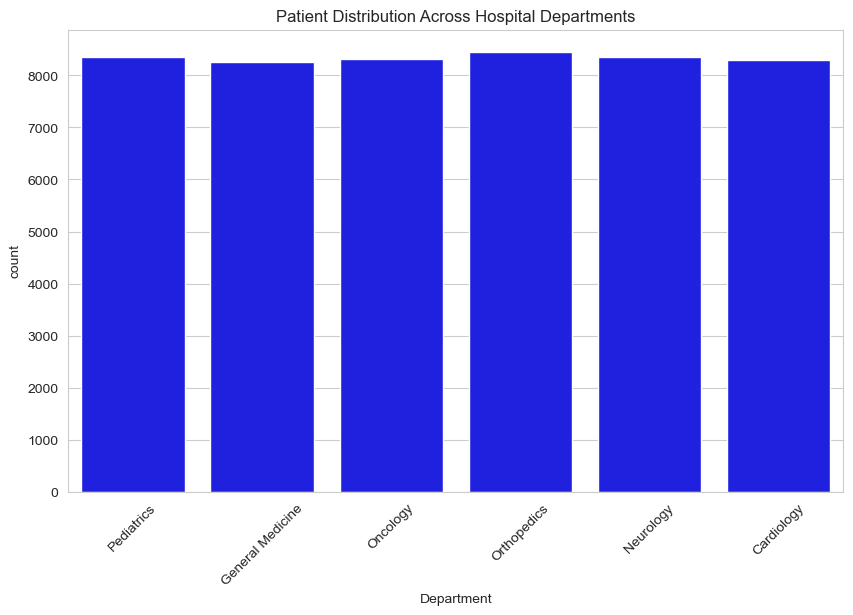

### **CONCLUSION**

### **This bar chart shows the distribution of patients across hospital departments. Departments with higher patient counts indicate greater healthcare demand and may require more medical staff and resources.**

In [12]:
# BAR CHART — Department Wise Patient Distribution

plt.figure(figsize=(10,6))
sns.countplot(x='Department', data=df, color='blue')

plt.title("Patient Distribution Across Hospital Departments")
plt.xticks(rotation=45)

plt.show()

display(Markdown("### **CONCLUSION**"))
display(Markdown("### **This bar chart shows the distribution of patients across hospital departments. Departments with higher patient counts indicate greater healthcare demand and may require more medical staff and resources.**"))

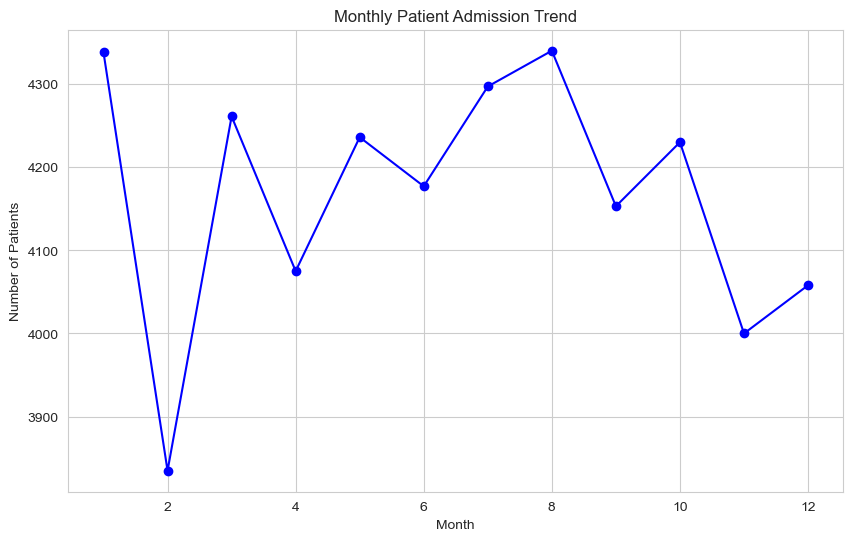

### **CONCLUSION**

### **This line chart illustrates patient admission trends throughout the year. It helps hospitals understand seasonal patterns in healthcare demand and prepare resources accordingly.**

In [13]:
# LINE CHART — Monthly Patient Admissions

df['Month'] = df['Admission_Date'].dt.month
monthly_admissions = df.groupby('Month').size()

plt.figure(figsize=(10,6))
plt.plot(monthly_admissions.index, monthly_admissions.values, marker='o', color='blue')

plt.title("Monthly Patient Admission Trend")
plt.xlabel("Month")
plt.ylabel("Number of Patients")

plt.show()

display(Markdown("### **CONCLUSION**"))
display(Markdown("### **This line chart illustrates patient admission trends throughout the year. It helps hospitals understand seasonal patterns in healthcare demand and prepare resources accordingly.**"))

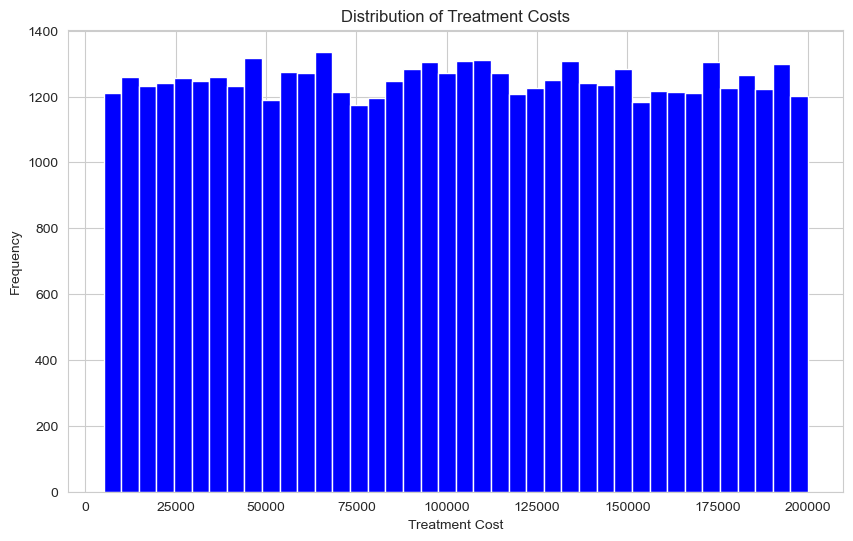

### **CONCLUSION**

### **The histogram shows how treatment costs are distributed across patients. It highlights the most common cost ranges and helps hospitals analyze financial trends.**

In [14]:
# HISTOGRAM — Treatment Cost Distribution

plt.figure(figsize=(10,6))
plt.hist(df['Treatment_Cost'], bins=40, color='blue')

plt.title("Distribution of Treatment Costs")
plt.xlabel("Treatment Cost")
plt.ylabel("Frequency")

plt.show()

display(Markdown("### **CONCLUSION**"))
display(Markdown("### **The histogram shows how treatment costs are distributed across patients. It highlights the most common cost ranges and helps hospitals analyze financial trends.**"))

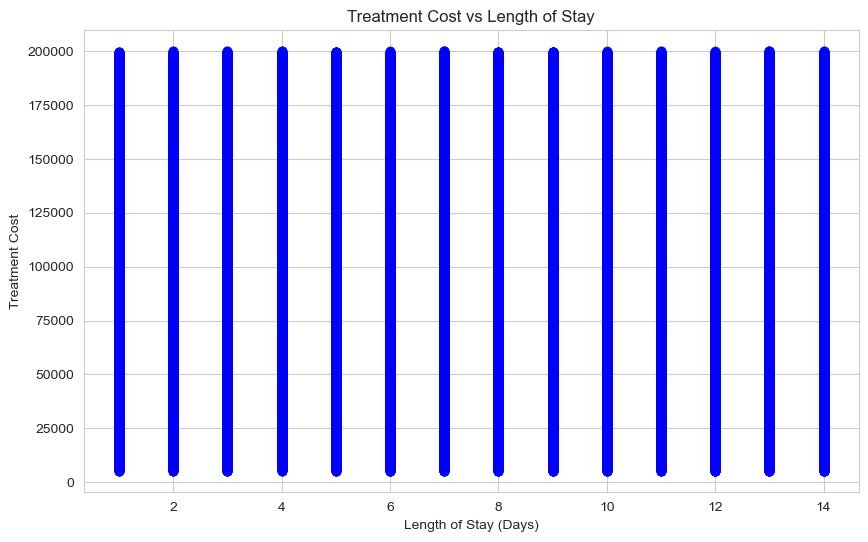

### **CONCLUSION**

### **This scatter plot shows the relationship between patient stay duration and treatment cost. Generally, longer hospital stays tend to increase treatment costs.**

In [15]:
# SCATTER PLOT — Treatment Cost vs Length of Stay

plt.figure(figsize=(10,6))
plt.scatter(df['Length_of_Stay_Days'], df['Treatment_Cost'], color='blue')

plt.title("Treatment Cost vs Length of Stay")
plt.xlabel("Length of Stay (Days)")
plt.ylabel("Treatment Cost")

plt.show()

display(Markdown("### **CONCLUSION**"))
display(Markdown("### **This scatter plot shows the relationship between patient stay duration and treatment cost. Generally, longer hospital stays tend to increase treatment costs.**"))

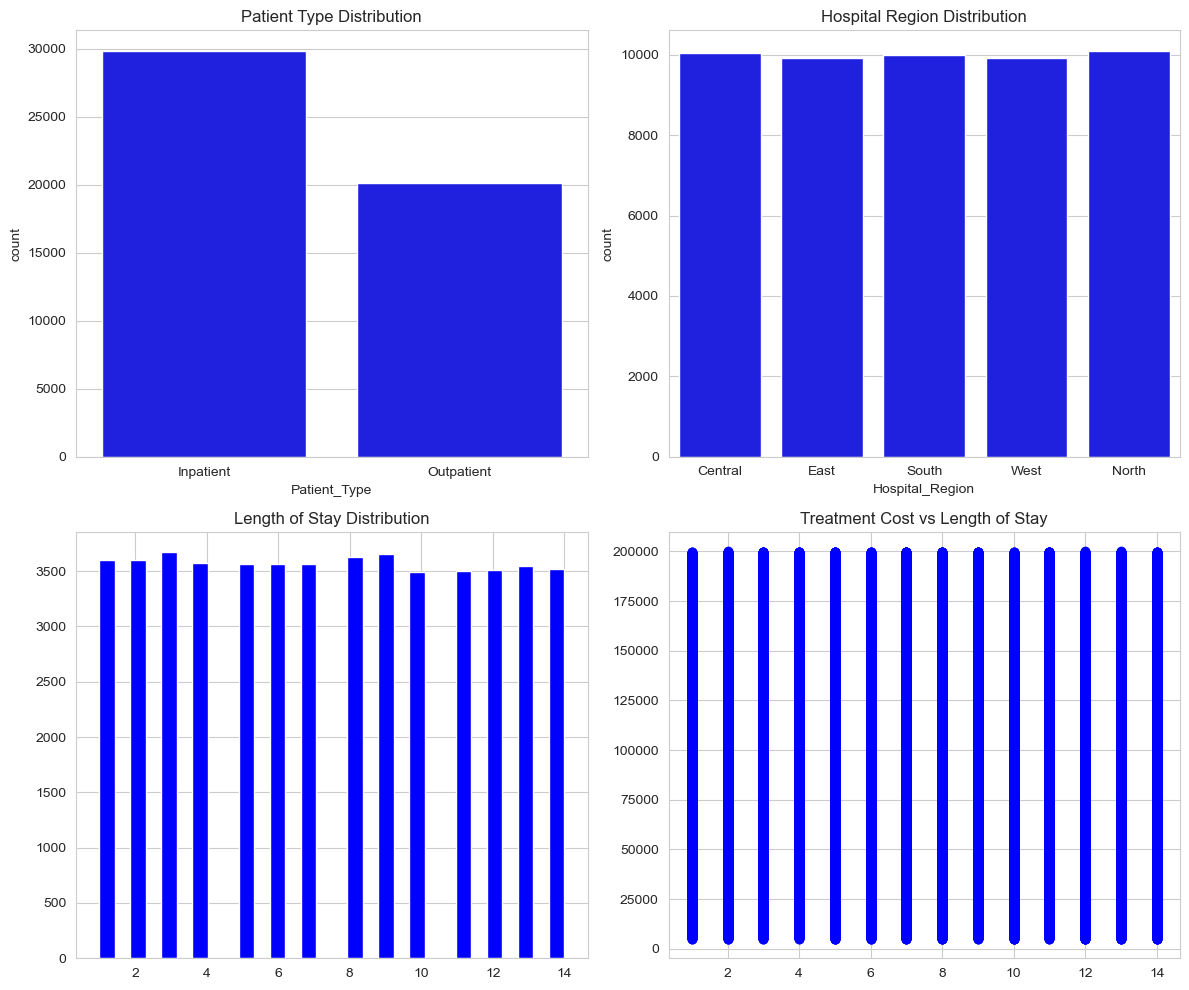

### **CONCLUSION**

### **Subplots combine multiple insights into one visualization, helping analyze patient type distribution, hospital regions, and hospital stay patterns simultaneously.**

In [17]:
# SUBPLOTS — Combined Insights

fig, axes = plt.subplots(2,2, figsize=(12,10))

sns.countplot(x='Patient_Type', data=df, ax=axes[0,0], color='blue')
axes[0,0].set_title("Patient Type Distribution")

sns.countplot(x='Hospital_Region', data=df, ax=axes[0,1], color='blue')
axes[0,1].set_title("Hospital Region Distribution")

axes[1,0].hist(df['Length_of_Stay_Days'], bins=30, color='blue')
axes[1,0].set_title("Length of Stay Distribution")

axes[1,1].scatter(df['Length_of_Stay_Days'], df['Treatment_Cost'], color='blue')
axes[1,1].set_title("Treatment Cost vs Length of Stay")

plt.tight_layout()
plt.show()

display(Markdown("### **CONCLUSION**"))
display(Markdown("### **Subplots combine multiple insights into one visualization, helping analyze patient type distribution, hospital regions, and hospital stay patterns simultaneously.**"))

## UNIQUE FEATURE: HOSPITAL EFFICIENCY SCORE

In this project, a **unique analytical metric** called the **Hospital Efficiency Score** is introduced.  
This score measures the relationship between **treatment cost** and the **length of hospital stay**.

### Formula Used
**Efficiency Score = Treatment Cost / Length of Stay (Days)**

### Purpose of the Metric
This metric helps evaluate how efficiently hospital resources are used.

- **Higher Efficiency Score** → Expensive treatments per day  
- **Lower Efficiency Score** → Longer stays with lower cost per day

This analysis helps hospitals monitor **operational performance**, improve **resource allocation**, and enhance **healthcare management efficiency**.

In [19]:
# SUMMARY TABLE

dept_summary = df.groupby('Department')[['Treatment_Cost','Length_of_Stay_Days']].mean()

dept_summary

,Treatment_Cost,Length_of_Stay_Days
Department,,
Cardiology,102229.530228,7.372873
General Medicine,102453.255270,7.517083
Neurology,102690.494607,7.440436
Oncology,102196.266747,7.564281
Orthopedics,101830.820558,7.455524
Pediatrics,103202.628325,7.430146


In [20]:
# RECOMMENDATIONS

display(Markdown("## **RECOMMENDATIONS**"))

display(Markdown("### **1. Hospitals should allocate more resources to departments with higher patient loads to improve service efficiency.**"))

display(Markdown("### **2. Treatment cost analysis should be used to identify expensive procedures and develop cost management strategies.**"))

display(Markdown("### **3. Regions with high patient admissions should receive better healthcare infrastructure and additional medical facilities.**"))

display(Markdown("### **4. Patient stay duration insights can help hospitals optimize bed management systems and reduce overcrowding.**"))

display(Markdown("### **5. The Hospital Efficiency Score developed in this project can be used as a performance indicator to monitor and improve operational efficiency across departments.**"))

## **RECOMMENDATIONS**

### **1. Hospitals should allocate more resources to departments with higher patient loads to improve service efficiency.**

### **2. Treatment cost analysis should be used to identify expensive procedures and develop cost management strategies.**

### **3. Regions with high patient admissions should receive better healthcare infrastructure and additional medical facilities.**

### **4. Patient stay duration insights can help hospitals optimize bed management systems and reduce overcrowding.**

### **5. The Hospital Efficiency Score developed in this project can be used as a performance indicator to monitor and improve operational efficiency across departments.**

In [21]:
# FINAL DATASET CHECK

print("Final Dataset Shape:")
print(df.shape)

Final Dataset Shape:
(50000, 11)
